# 📍 K-Nearest Neighbors (KNN) Classifier

A completely different philosophy from Logistic Regression: KNN learns **no parameters at all**. To classify a new point, it simply looks at the $k$ closest training examples and takes a majority vote — "you are the average of your neighbors," made literal.

📖 Full mathematical explanation (distance metrics, curse of dimensionality, bias-variance vs $k$): [README.md](README.md)


## 1. Setup & Dataset

A 2D synthetic dataset for visualizing decision boundaries, plus the real-world Wine dataset (from the [Datasets catalog](https://github.com/mdnuruzzamanKALLOL/Datasets)) for a full end-to-end application later.


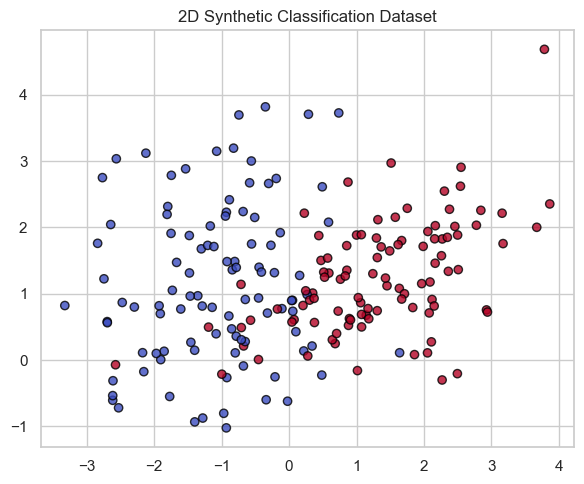

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.spatial.distance import euclidean, cityblock, minkowski

sns.set_theme(style="whitegrid")
np.random.seed(42)

X_2d, y_2d = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.2, random_state=42
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
ax.set_title("2D Synthetic Classification Dataset")
plt.tight_layout()
plt.show()


## 2. Distance Metrics

KNN's entire behavior hinges on "closeness" — and how you define distance changes the answer. Formulas in the README; here we compare the three most common metrics on the same pair of points.


In [2]:
point_a = np.array([0, 0])
point_b = np.array([3, 4])

print(f"Euclidean distance  (straight line):     {euclidean(point_a, point_b):.3f}")
print(f"Manhattan distance  (grid/city-block):    {cityblock(point_a, point_b):.3f}")
print(f"Minkowski distance, p=3 (generalization): {minkowski(point_a, point_b, p=3):.3f}")
print("\n-> Minkowski with p=2 equals Euclidean, p=1 equals Manhattan -- both are special cases (see README).")


Euclidean distance  (straight line):     5.000
Manhattan distance  (grid/city-block):    7.000
Minkowski distance, p=3 (generalization): 4.498

-> Minkowski with p=2 equals Euclidean, p=1 equals Manhattan -- both are special cases (see README).


## 3. KNN From Scratch

No `.fit()` in the traditional sense — KNN just *memorizes* the training data. All the real work happens at prediction time: compute distance to every training point, sort, take the majority vote among the $k$ closest.


In [3]:
def knn_predict_single(X_train, y_train, query_point, k=5):
    distances = np.sqrt(((X_train - query_point) ** 2).sum(axis=1))   # Euclidean distance to every training point
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_train[nearest_indices]
    values, counts = np.unique(nearest_labels, return_counts=True)
    majority_class = values[np.argmax(counts)]
    return majority_class, nearest_indices, distances[nearest_indices]

query = np.array([0.5, 0.5])
predicted_class, neighbor_idx, neighbor_dist = knn_predict_single(X_2d, y_2d, query, k=5)

print(f"Query point: {query}")
print(f"Predicted class: {predicted_class}")
print(f"5 nearest neighbor distances: {neighbor_dist.round(3)}")


Query point: [0.5 0.5]
Predicted class: 1
5 nearest neighbor distances: [0.14  0.228 0.24  0.312 0.329]


## 4. Visualizing a Single Prediction

Seeing exactly which training points "voted" on a query point makes KNN's mechanism completely transparent — there's no hidden parameter, just literal nearby examples.


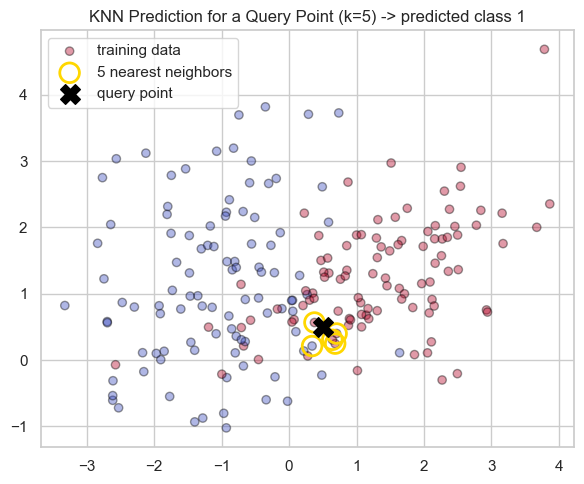

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.4, label="training data")
ax.scatter(X_2d[neighbor_idx, 0], X_2d[neighbor_idx, 1], facecolor="none", edgecolor="gold", s=200, linewidth=2, label="5 nearest neighbors")
ax.scatter(*query, color="black", marker="X", s=200, label="query point", zorder=5)
ax.set_title(f"KNN Prediction for a Query Point (k=5) -> predicted class {predicted_class}")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Comparing Against scikit-learn

Verifying the from-scratch implementation matches `KNeighborsClassifier` exactly — since there's no optimization involved (just distance + voting), they should agree perfectly, unlike Logistic Regression's approximate match.


In [5]:
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_2d, y_2d)

sklearn_pred = sklearn_knn.predict(query.reshape(1, -1))[0]
print(f"From-scratch prediction: {predicted_class}")
print(f"sklearn prediction:      {sklearn_pred}")
print(f"Match: {predicted_class == sklearn_pred}")

# Verify across many random query points, not just one
random_queries = np.random.uniform(X_2d.min(), X_2d.max(), size=(50, 2))
scratch_preds = [knn_predict_single(X_2d, y_2d, q, k=5)[0] for q in random_queries]
sklearn_preds = sklearn_knn.predict(random_queries)
print(f"\nAgreement across 50 random query points: {np.mean(np.array(scratch_preds) == sklearn_preds):.1%}")


From-scratch prediction: 1
sklearn prediction:      1
Match: True

Agreement across 50 random query points: 100.0%


## 6. The Effect of $k$ — Decision Boundary Comparison

Small $k$ (e.g. 1) creates a jagged, overfit boundary that chases individual noisy points. Large $k$ creates a smooth, underfit boundary that ignores local structure. This is the bias-variance tradeoff (Model Evaluation & Tuning, later) made directly visible.


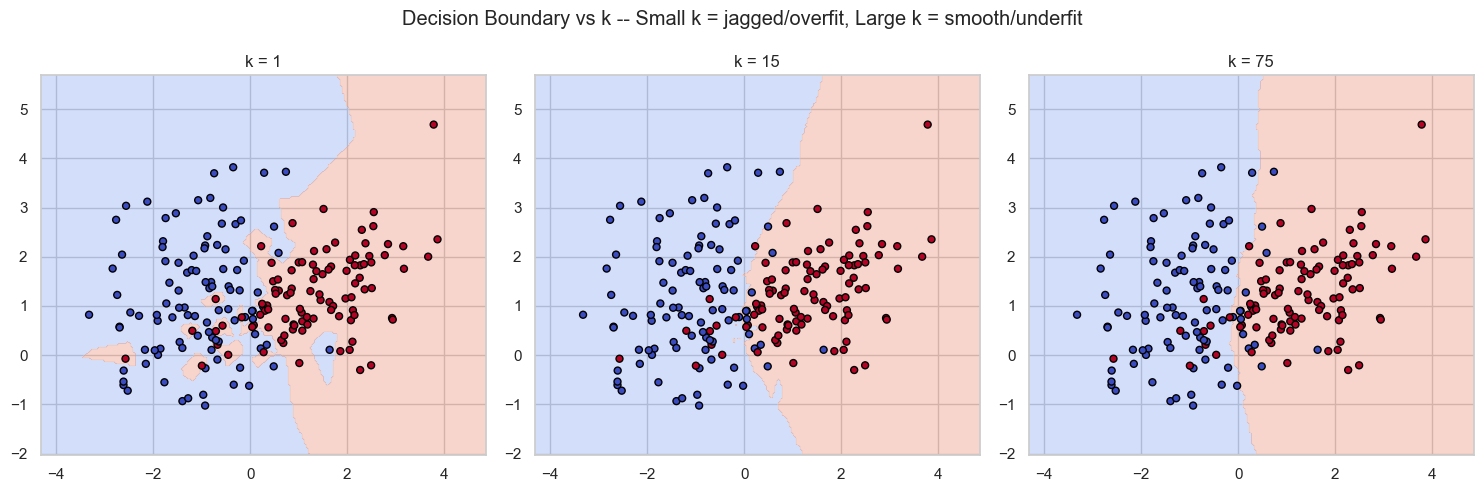

In [6]:
def plot_knn_boundary(ax, X, y, k):
    model = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    x1_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    x2_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
    xx1, xx2 = np.meshgrid(x1_range, x2_range)
    preds = model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    ax.contourf(xx1, xx2, preds, levels=2, cmap="coolwarm", alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=25)
    ax.set_title(f"k = {k}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, [1, 15, 75]):
    plot_knn_boundary(ax, X_2d, y_2d, k)
plt.suptitle("Decision Boundary vs k -- Small k = jagged/overfit, Large k = smooth/underfit")
plt.tight_layout()
plt.show()


## 7. Choosing $k$ — Cross-Validated Error Curve

Rather than guessing, sweep $k$ across a range and pick the value that minimizes cross-validated error — the same model-selection principle used throughout the Model Evaluation & Tuning notebooks, applied here to KNN's one real hyperparameter.


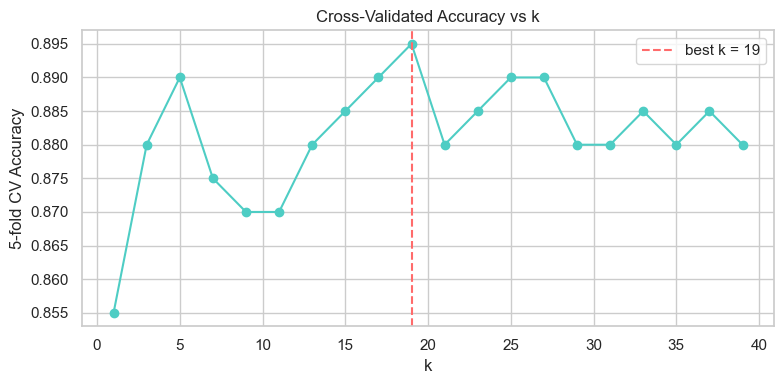

Best k: 19, CV accuracy: 0.8950


In [7]:
k_range = range(1, 41, 2)
cv_scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_2d, y_2d, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = list(k_range)[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), cv_scores, marker="o", color="#4ecdc4")
ax.axvline(best_k, color="#ff6b6b", linestyle="--", label=f"best k = {best_k}")
ax.set_xlabel("k"); ax.set_ylabel("5-fold CV Accuracy")
ax.set_title("Cross-Validated Accuracy vs k")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best k: {best_k}, CV accuracy: {max(cv_scores):.4f}")


## 8. Weighted vs Uniform Voting

Uniform voting treats all $k$ neighbors equally, regardless of how close each actually is. **Distance-weighted** voting gives closer neighbors more say — often more accurate near class boundaries, where the nearest single point is more informative than the 10th-nearest.


In [8]:
uniform_model = KNeighborsClassifier(n_neighbors=15, weights="uniform")
distance_model = KNeighborsClassifier(n_neighbors=15, weights="distance")

uniform_scores = cross_val_score(uniform_model, X_2d, y_2d, cv=5).mean()
distance_scores = cross_val_score(distance_model, X_2d, y_2d, cv=5).mean()

print(f"Uniform weighting  CV accuracy: {uniform_scores:.4f}")
print(f"Distance weighting CV accuracy: {distance_scores:.4f}")
print("\n-> Distance weighting lets very close neighbors dominate the vote, which can help or hurt")
print("   depending on how noisy the closest points are -- worth trying both, never assume.")


Uniform weighting  CV accuracy: 0.8850
Distance weighting CV accuracy: 0.9000

-> Distance weighting lets very close neighbors dominate the vote, which can help or hurt
   depending on how noisy the closest points are -- worth trying both, never assume.


## 9. Feature Scaling Is Not Optional for KNN

Since KNN's entire decision is based on distance, an unscaled feature with a larger numeric range **completely dominates** the distance calculation — a textbook case of why topic 03's scaling step matters, made concrete.


In [9]:
# Simulate two features on wildly different scales
X_unscaled = np.column_stack([
    np.random.normal(50, 10, 200),      # e.g. age: range ~20-80
    np.random.normal(50000, 15000, 200) # e.g. income: range ~10000-100000
])
y_unscaled = (X_unscaled[:, 0] > 50).astype(int)   # true pattern depends ONLY on the first feature

knn_unscaled = KNeighborsClassifier(n_neighbors=5).fit(X_unscaled, y_unscaled)
acc_unscaled = cross_val_score(knn_unscaled, X_unscaled, y_unscaled, cv=5).mean()

X_scaled = StandardScaler().fit_transform(X_unscaled)
knn_scaled = KNeighborsClassifier(n_neighbors=5).fit(X_scaled, y_unscaled)
acc_scaled = cross_val_score(knn_scaled, X_scaled, y_unscaled, cv=5).mean()

print(f"Accuracy WITHOUT scaling (income dominates distance): {acc_unscaled:.4f}")
print(f"Accuracy WITH scaling (both features contribute fairly): {acc_scaled:.4f}")
print("\n-> Unscaled income (range ~90,000) swamps age (range ~60) in the distance formula,")
print("   even though the true label only depends on age.")


Accuracy WITHOUT scaling (income dominates distance): 0.5250
Accuracy WITH scaling (both features contribute fairly): 0.9800

-> Unscaled income (range ~90,000) swamps age (range ~60) in the distance formula,
   even though the true label only depends on age.


## 10. The Curse of Dimensionality

As the number of features grows, distances between points become increasingly similar — "nearest" and "farthest" start to lose meaning. This is a fundamental limitation of any distance-based method, not just an implementation detail.


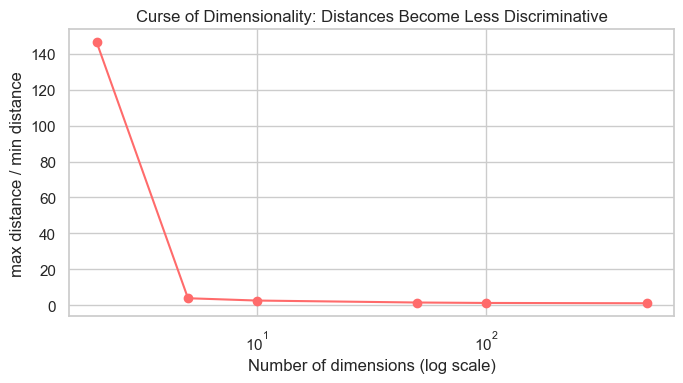

dimensions=   2: farthest/nearest ratio = 146.257
dimensions=   5: farthest/nearest ratio = 3.931
dimensions=  10: farthest/nearest ratio = 2.644
dimensions=  50: farthest/nearest ratio = 1.550
dimensions= 100: farthest/nearest ratio = 1.305
dimensions= 500: farthest/nearest ratio = 1.134

-> As dimensions grow, this ratio approaches 1 -- every point becomes 'equally far' from every other,
   which is exactly why KNN struggles on very high-dimensional data without dimensionality reduction (PCA).


In [10]:
def distance_ratio_by_dimension(n_dims_list, n_points=1000):
    ratios = []
    for d in n_dims_list:
        points = np.random.uniform(0, 1, size=(n_points, d))
        origin = np.zeros(d)
        dists = np.sqrt(((points - origin) ** 2).sum(axis=1))
        ratios.append(dists.max() / dists.min())   # how different is farthest vs nearest?
    return ratios

dims = [2, 5, 10, 50, 100, 500]
ratios = distance_ratio_by_dimension(dims)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dims, ratios, marker="o", color="#ff6b6b")
ax.set_xscale("log")
ax.set_xlabel("Number of dimensions (log scale)")
ax.set_ylabel("max distance / min distance")
ax.set_title("Curse of Dimensionality: Distances Become Less Discriminative")
plt.tight_layout()
plt.show()

for d, r in zip(dims, ratios):
    print(f"dimensions={d:>4}: farthest/nearest ratio = {r:.3f}")
print("\n-> As dimensions grow, this ratio approaches 1 -- every point becomes 'equally far' from every other,")
print("   which is exactly why KNN struggles on very high-dimensional data without dimensionality reduction (PCA).")


## 11. KNN for Regression (a Quick Aside)

KNN isn't limited to classification — `KNeighborsRegressor` predicts the **average** (or weighted average) of the $k$ nearest neighbors' target values instead of taking a majority vote. Same core algorithm, different aggregation at the end.


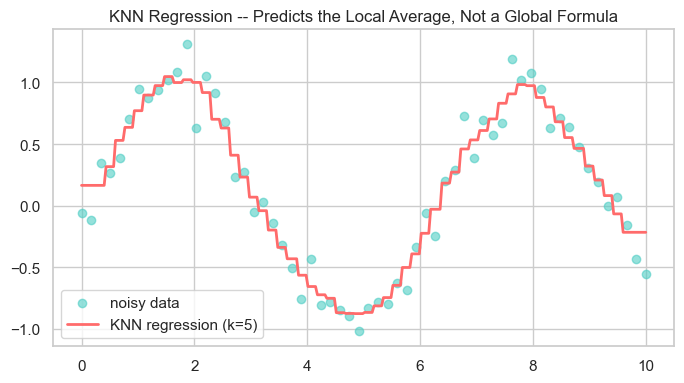

In [11]:
from sklearn.neighbors import KNeighborsRegressor

x_reg = np.linspace(0, 10, 60).reshape(-1, 1)
y_reg = np.sin(x_reg).ravel() + np.random.normal(0, 0.15, 60)

reg_model = KNeighborsRegressor(n_neighbors=5).fit(x_reg, y_reg)
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)
y_plot = reg_model.predict(x_plot)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_reg, y_reg, color="#4ecdc4", alpha=0.6, label="noisy data")
ax.plot(x_plot, y_plot, color="#ff6b6b", linewidth=2, label="KNN regression (k=5)")
ax.set_title("KNN Regression -- Predicts the Local Average, Not a Global Formula")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Real Dataset — Wine Classification

Applying the full pipeline (split → scale → tune k → evaluate) to the real Wine dataset — 13 chemical features, 3 cultivar classes, exactly the kind of tabular problem KNN handles well after scaling.


In [12]:
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Quick k sweep on the training data via cross-validation
k_range_wine = range(1, 21)
cv_scores_wine = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train, cv=5).mean() for k in k_range_wine]
best_k_wine = list(k_range_wine)[np.argmax(cv_scores_wine)]

final_model = KNeighborsClassifier(n_neighbors=best_k_wine)
final_model.fit(X_train_scaled, y_train)
test_preds = final_model.predict(X_test_scaled)

print(f"Best k (via CV on training data): {best_k_wine}")
print(f"Test accuracy: {accuracy_score(y_test, test_preds):.4f}")
print("\n", classification_report(y_test, test_preds, target_names=wine.target_names))


Best k (via CV on training data): 18
Test accuracy: 0.9722

               precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



## 13. Confusion Matrix — Wine Dataset

A quick visual check of exactly which classes, if any, get confused with each other.


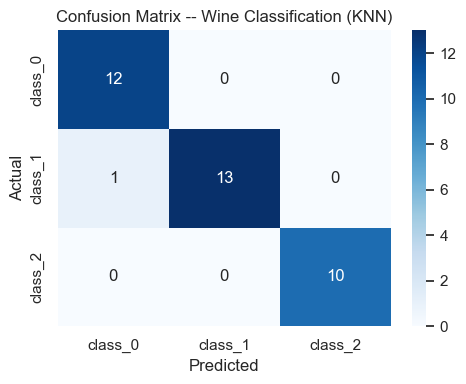

In [13]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
ax.set_title("Confusion Matrix -- Wine Classification (KNN)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 14. Distance Metric Choice — Effect on Real Accuracy

Section 2 compared distance metrics on a toy pair of points; here we check whether the choice actually matters for the Wine dataset's cross-validated accuracy.


In [14]:
for metric in ["euclidean", "manhattan", "chebyshev"]:
    model = KNeighborsClassifier(n_neighbors=best_k_wine, metric=metric)
    score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    print(f"metric={metric:12s} -> CV accuracy: {score:.4f}")

print("\n-> On well-scaled, roughly-continuous features like these, Euclidean and Manhattan")
print("   usually perform similarly; the gap widens more on sparse or high-dimensional data.")


metric=euclidean    -> CV accuracy: 0.9791
metric=manhattan    -> CV accuracy: 0.9719
metric=chebyshev    -> CV accuracy: 0.9369

-> On well-scaled, roughly-continuous features like these, Euclidean and Manhattan
   usually perform similarly; the gap widens more on sparse or high-dimensional data.


## 15. Class Imbalance's Effect on KNN

Majority voting has a subtle failure mode on imbalanced data: near a boundary, the majority class simply has more points nearby by sheer count, pulling votes toward it regardless of the true local pattern.


In [15]:
X_imb, y_imb = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.95, 0.05], class_sep=0.5, flip_y=0.03, random_state=7
)
print("Class distribution:", dict(zip(*np.unique(y_imb, return_counts=True))))

def minority_recall(model):
    preds = model.predict(X_imb)
    return ((preds == 1) & (y_imb == 1)).sum() / (y_imb == 1).sum()

recall_k_large_uniform = minority_recall(KNeighborsClassifier(n_neighbors=25, weights="uniform").fit(X_imb, y_imb))
recall_k_small_uniform = minority_recall(KNeighborsClassifier(n_neighbors=3, weights="uniform").fit(X_imb, y_imb))
recall_k_large_distance = minority_recall(KNeighborsClassifier(n_neighbors=25, weights="distance").fit(X_imb, y_imb))

print(f"\nMinority-class recall, k=25, uniform voting:  {recall_k_large_uniform:.3f}")
print(f"Minority-class recall, k=3,  uniform voting:  {recall_k_small_uniform:.3f}")
print(f"Minority-class recall, k=25, distance voting: {recall_k_large_distance:.3f}")
print("\n-> A large k with uniform voting lets the numerous majority class outvote genuine minority-class")
print("   neighborhoods; a smaller k or distance-weighting recovers minority recall -- same tradeoff as")
print("   the class-imbalance topic from Foundation, now visible directly in KNN's voting mechanism.")


Class distribution: {np.int64(0): np.int64(283), np.int64(1): np.int64(17)}

Minority-class recall, k=25, uniform voting:  0.000
Minority-class recall, k=3,  uniform voting:  0.412
Minority-class recall, k=25, distance voting: 1.000

-> A large k with uniform voting lets the numerous majority class outvote genuine minority-class
   neighborhoods; a smaller k or distance-weighting recovers minority recall -- same tradeoff as
   the class-imbalance topic from Foundation, now visible directly in KNN's voting mechanism.


## ✅ Key Takeaways

- KNN has **no training phase** — it memorizes data and does all its work at prediction time, the opposite of Logistic Regression's "learn parameters once, predict cheaply forever."
- Small $k$ → low bias, high variance (jagged, overfit boundary). Large $k$ → high bias, low variance (smooth, underfit boundary) — always tune $k$ via cross-validation, never guess.
- **Feature scaling is mandatory**, not optional, for any distance-based method — an unscaled feature with a larger numeric range silently dominates every distance calculation.
- The **curse of dimensionality** means KNN's core assumption ("nearby points are similar") weakens as feature count grows — pair with PCA/feature selection on high-dimensional data.
- The same algorithm handles both classification (majority vote) and regression (average) — only the aggregation step at the end changes.
- KNN prediction cost scales with training set size (compute distance to every point) — efficient structures like KD-trees/Ball-trees (what `sklearn`'s `algorithm="auto"` picks automatically) matter at scale.

**Next up:** [03_Naive_Bayes](../03_Naive_Bayes/) — a probabilistic classifier built directly from the Math Refresher's Bayes' theorem.
